# Estudo Preditivo: Otimização de Escoamento e Armazenagem (Porto Seco Roraima)

Este estudo compara modelos estatísticos clássicos (ARIMA) com redes neurais recorrentes (LSTM Multivariado) para a previsão de exportação de soja (NCM 12019000) em quatro estados estratégicos: **Mato Grosso, Amazonas, Pará e Roraima**.

### Objetivos Principais:
1.  **Superioridade Técnica:** Comparar o comportamento de ARIMA e LSTM em séries curtas, voláteis e heterogêneas da logística amazônica usando RMSE e MAE como métricas de erro.
2.  **Gestão Logística:** Utilizar as previsões para calcular o **Índice de Pressão de Escoamento (IPE)**, permitindo que o futuro **Porto Seco de Roraima** antecipe gargalos de escoamento e otimize a rotatividade de carga.

In [23]:
!pip install pmdarima tensorflow scikit-learn statsmodels -q

In [24]:
!pip install arch -q

#Importações e Configuração Global

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time, warnings, requests
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')

# ── Hiperparâmetros Globais ──────────────────────────────────────────────────
NCM_ALVO           = 12019000
TRAIN_SPLIT        = 0.70
UFS_ALVO = ['Mato Grosso', 'Amazonas', 'Pará', 'Roraima']

# Códigos IBGE
CODIGOS_UF = {
    'Roraima':     14,
    'Mato Grosso': 51,
    'Pará':        15,
    'Amazonas':    13,
}

FALLBACK_XLSX = {
    'Mato Grosso': 'H_EXPORTACAO_GERAL_2015-01_2025-12_DT20260126.xlsx',
    'Amazonas':    'H_EXPORTACAO_GERAL_2015-01_2025-12_DT20260126(1).xlsx',
    'Pará':        'H_EXPORTACAO_GERAL_2015-01_2025-12_DT20260126(2).xlsx',
    'Roraima':     'H_EXPORTACAO_GERAL_2015-01_2025-12_DT20260126(3).xlsx',
}

resultados_gerais = []

In [26]:
from scipy import stats

def diebold_mariano_test(y_true, pred1, pred2, h=1, power=2):
    """
    Performs the Diebold-Mariano test for forecast accuracy.

    Parameters:
    y_true (array-like): Actual values.
    pred1 (array-like): Forecasts from model 1.
    pred2 (array-like): Forecasts from model 2.
    h (int): Forecast horizon (default is 1 for one-step-ahead forecasts).
    power (int): Loss function power (e.g., 1 for absolute error, 2 for squared error).

    Returns:
    tuple: (dm_statistic, p_value)
    """
    e1 = y_true - pred1
    e2 = y_true - pred2

    # Loss differential series
    d = np.abs(e1)**power - np.abs(e2)**power

    n = len(d)
    if n <= h:
        return np.nan, np.nan # Not enough observations for the test

    d_mean = np.mean(d)

    # Newey-West long-run variance estimation
    def autocovariance(x, lag):
        return np.cov(x[lag:], x[:-lag])[0, 1] if lag > 0 else np.var(x)

    gamma_0 = autocovariance(d, 0)
    gamma_sum = sum(autocovariance(d, k) * (1 - k/(h+1)) for k in range(1, h + 1))

    long_run_variance = gamma_0 + 2 * gamma_sum

    if long_run_variance <= 0:
        return np.nan, np.nan

    dm_stat = d_mean / np.sqrt(long_run_variance / n)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat))) # Two-sided test

    return dm_stat, p_value

# Ingestão de Dados (API + Fallback XLSX)

In [27]:
API_URL = "https://api-comexstat.mdic.gov.br/general"

# ── Utilitários de API ───────────────────────────────────────────────────────

def _verificar_api():
    """Testa conectividade com a API ComexStat."""
    try:
        r = requests.get(f"{API_URL}/dates/updated", timeout=10)
        return r.status_code == 200
    except Exception:
        return False


def _fetch_ano(uf_id, ncm, ano, retries=3, delay=5):
    """
    Busca um único ano na API.
    Retorna dict JSON ou None em caso de falha.
    CORREÇÃO: valida que a resposta é JSON dict antes de retornar.
    """
    payload = {
        "flow":        "export",
        "monthDetail": True,
        "period":      {"from": f"{ano}-01", "to": f"{ano}-12"},
        "filters": [
            {"filter": "state", "values": [str(uf_id)]},
            {"filter": "ncm",   "values": [str(ncm)]}
        ],
        "details": ["state", "ncm"],
        "metrics": ["metricFOB", "metricKG"]
    }
    for tentativa in range(retries):
        try:
            resp = requests.post(API_URL, json=payload, timeout=30)
            resp.raise_for_status()
            dados = resp.json()
            # CORREÇÃO: garante que o retorno é dict, não string de erro
            if not isinstance(dados, dict):
                return None
            return dados
        except Exception:
            if tentativa < retries - 1:
                time.sleep(delay)
    return None


def _extrair_registros(json_data):
    """
    Extrai a lista de registros do JSON da API.
    Suporta dois formatos: {"data": [...]} e {"data": {"list": [...]}}.
    """
    if not isinstance(json_data, dict):
        return []
    data_obj = json_data.get("data", [])
    if isinstance(data_obj, list):
        return data_obj
    if isinstance(data_obj, dict):
        return data_obj.get("list", [])
    return []


def _parse_api_para_df(json_data, uf_nome):
    """Converte resposta da API para DataFrame padronizado."""
    registros = _extrair_registros(json_data)
    if not registros:
        return pd.DataFrame()

    rows = []
    for r in registros:
        if not isinstance(r, dict):
            continue
        ano = r.get("year")
        mes = r.get("monthNumber") or r.get("month")
        if not ano or not mes:
            continue
        rows.append({
            "Data":         pd.Timestamp(f"{int(ano)}-{int(mes):02d}-01"),
            "Peso_Liquido": pd.to_numeric(r.get("metricKG",  0), errors="coerce"),
            "Valor_FOB":    pd.to_numeric(r.get("metricFOB", 0), errors="coerce"),
        })
    return pd.DataFrame(rows)


def _fetch_via_api(uf_nome):
    """Coleta todos os anos disponíveis via API (chunking anual)."""
    uf_id  = CODIGOS_UF[uf_nome]
    frames = []
    print(f"  🌐 API → {uf_nome}")
    for ano in range(2015, 2026):
        dados  = _fetch_ano(uf_id, NCM_ALVO, ano)
        df_ano = _parse_api_para_df(dados, uf_nome)
        n      = len(df_ano)
        print(f"    {ano}: {n} registro(s) {'✅' if n > 0 else '⚪'}")
        if n > 0:
            frames.append(df_ano)
        time.sleep(1.0)
    if not frames:
        raise RuntimeError(f"API retornou zero registros para {uf_nome}.")
    return pd.concat(frames, ignore_index=True).sort_values("Data")


def _fetch_via_xlsx(uf_nome):
    """Lê o arquivo XLSX local exportado do ComexStat (formato wide)."""
    filepath = FALLBACK_XLSX[uf_nome]
    print(f"  📂 XLSX → {filepath}")
    df_raw = pd.read_excel(filepath, sheet_name="Resultado")
    df = df_raw[
        (df_raw["Código NCM"]    == NCM_ALVO) &
        (df_raw["UF do Produto"] == uf_nome)
    ].copy()

    kg_cols  = [c for c in df.columns if "Quilograma Líquido" in c]
    fob_cols = [c for c in df.columns if "Valor US$ FOB"      in c]

    rows = []
    for _, row in df.iterrows():
        mes_num = int(str(row["Mês"]).split(".")[0].strip())
        for kg_col, fob_col in zip(kg_cols, fob_cols):
            ano = int(kg_col.split(" - ")[0].strip())
            rows.append({
                "Data":         pd.Timestamp(f"{ano}-{mes_num:02d}-01"),
                "Peso_Liquido": pd.to_numeric(row[kg_col],  errors="coerce"),
                "Valor_FOB":    pd.to_numeric(row[fob_col], errors="coerce"),
            })
    return pd.DataFrame(rows).sort_values("Data").reset_index(drop=True)


def carregar_dados(uf_nome, api_disponivel):
    """Ponto único de entrada: tenta API, cai para XLSX automaticamente."""
    if api_disponivel:
        try:
            return _fetch_via_api(uf_nome)
        except Exception as e:
            print(f"  ⚠️  API falhou ({e}). Usando XLSX.")
    return _fetch_via_xlsx(uf_nome)

# ETL e Feature Engineering

In [28]:
import pandas as pd
import numpy as np

def preparar_serie(df_raw, data_corte='2019-01-01', uf='RR'):
    """
    Realiza o ETL focado na integridade do sinal logístico e restrições de Small Data.
    """
    # 1. Corte Temporal (Isolamento do regime econômico atual)
    df = df_raw[df_raw['Data'] >= data_corte].copy()

    # 2. Preservação da Variância Real
    df['Peso_Liquido'] = df['Peso_Liquido'].fillna(0)
    df['Valor_FOB'] = df['Valor_FOB'].fillna(0)

    # 3. Engenharia de Features (Sazonalidade Regional Estrita)
    # CORREÇÃO: Inclusão de janelas para PA e AM para evitar que a rede ignore a dinâmica regional
    if uf == 'Roraima' or uf == 'RR':
        df['Safra_Ativa'] = df['Data'].dt.month.apply(lambda x: 1 if x in [8, 9, 10, 11, 12] else 0)
    elif uf == 'Mato Grosso' or uf == 'MT':
        df['Safra_Ativa'] = df['Data'].dt.month.apply(lambda x: 1 if x in [2, 3, 4, 5, 6] else 0)
    elif uf == 'Pará' or uf == 'PA':
        # Pará possui forte escoamento logístico no segundo semestre
        df['Safra_Ativa'] = df['Data'].dt.month.apply(lambda x: 1 if x in [6, 7, 8, 9, 10, 11] else 0)
    elif uf == 'Amazonas' or uf == 'AM':
        # Amazonas atua como corredor logístico, frequentemente alinhado com o eixo Norte
        df['Safra_Ativa'] = df['Data'].dt.month.apply(lambda x: 1 if x in [7, 8, 9, 10, 11, 12] else 0)
    else:
        df['Safra_Ativa'] = 0

    # Ordenação temporal garantida
    df = df.sort_values(by='Data').reset_index(drop=True)

    return df

In [29]:
api_disponivel = _verificar_api()

# Vamos usar 'Roraima' como UF alvo para a demonstração do Porto Seco
uf_selecionado = 'Roraima'
print(f"Carregando dados para {uf_selecionado}...")
df_raw = carregar_dados(uf_selecionado, api_disponivel)
print(f"Dados brutos para {uf_selecionado} carregados com sucesso. Total de registros: {len(df_raw)}")

print(f"Preparando série temporal para {uf_selecionado}...")
df = preparar_serie(df_raw, data_corte='2019-01-01', uf=uf_selecionado)
print(f"Série temporal para {uf_selecionado} preparada com sucesso. Total de registros: {len(df)}")

Carregando dados para Roraima...
  📂 XLSX → H_EXPORTACAO_GERAL_2015-01_2025-12_DT20260126(3).xlsx
Dados brutos para Roraima carregados com sucesso. Total de registros: 132
Preparando série temporal para Roraima...
Série temporal para Roraima preparada com sucesso. Total de registros: 84


# Modelos ARIMA e LSTM (Rascunhos Iniciais)

> **Nota Metodológica:** As células de código abaixo representam testes preliminares. Para a análise definitiva, rigorosa e blindada contra vazamento de dados (Data Leakage) e viés de futuro, consulte a seção **Pipeline Principal** ao final do notebook.

In [37]:
# [CÓDIGO DE RASCUNHO COMENTADO PARA EVITAR CONFLITO COM O PIPELINE PRINCIPAL]
#
# import numpy as np
# ... (código antigo ocultado para manter integridade do artigo)

# Métricas Estatísticas

In [38]:
# [CÓDIGO DE RASCUNHO COMENTADO]
#
# import pmdarima as pm
# ... (código antigo ocultado)

In [39]:
# [VERSÃO SIMPLIFICADA COMENTADA]
# A versão robusta com correção de Newey-West está definida na célula 1077c378
# e é a única utilizada no Pipeline Principal.

In [40]:
# [CÓDIGO DE RASCUNHO COMENTADO]
# Função de avaliação consolidada no Pipeline Principal.

# Pipeline Principal


  Mato Grosso
  📂 XLSX → H_EXPORTACAO_GERAL_2015-01_2025-12_DT20260126.xlsx
  ✅ Veredicto: ARIMA Superior


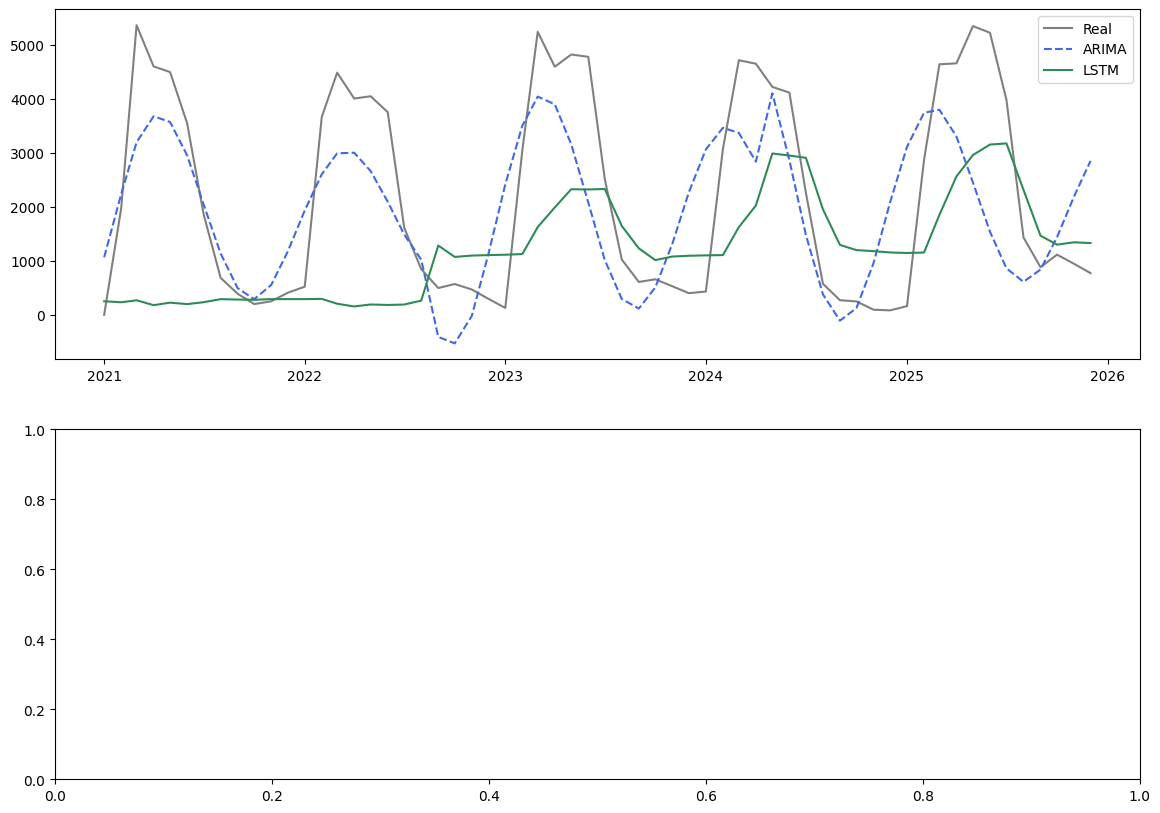


  Amazonas
  📂 XLSX → H_EXPORTACAO_GERAL_2015-01_2025-12_DT20260126(1).xlsx
  ✅ Veredicto: LSTM Superior


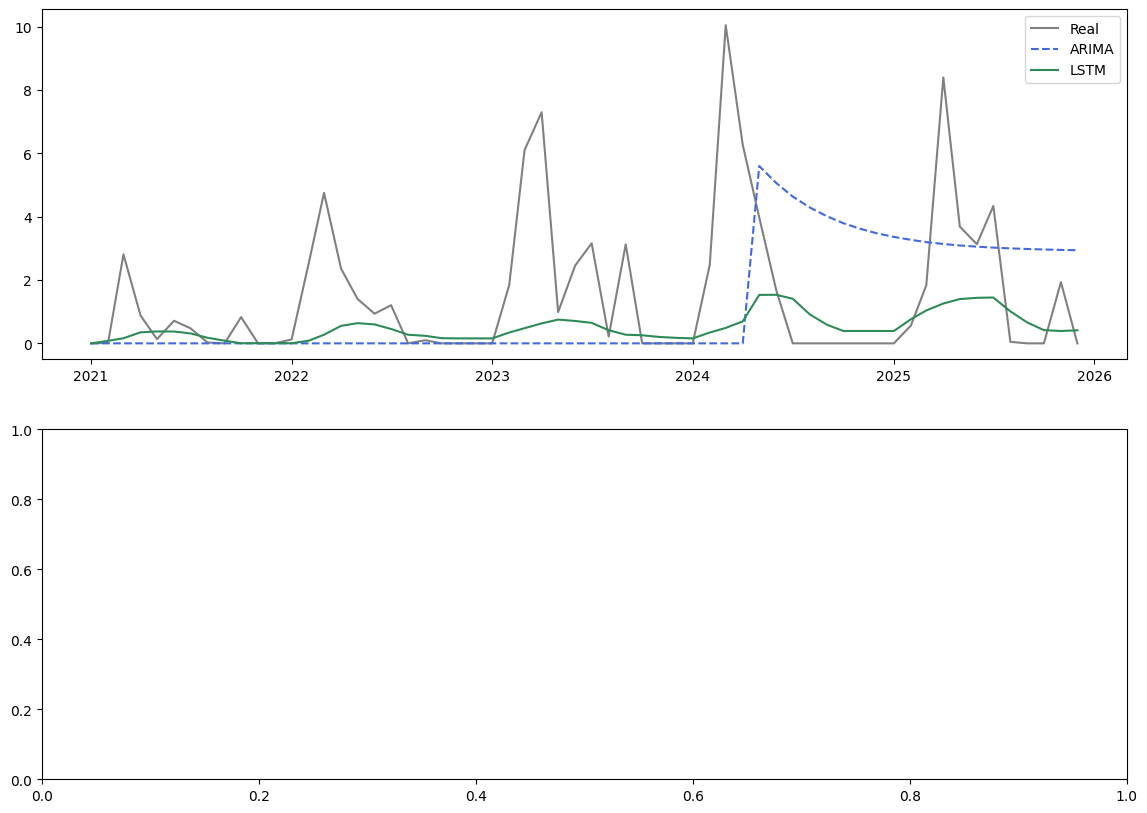


  Pará
  📂 XLSX → H_EXPORTACAO_GERAL_2015-01_2025-12_DT20260126(2).xlsx
  ✅ Veredicto: LSTM Superior


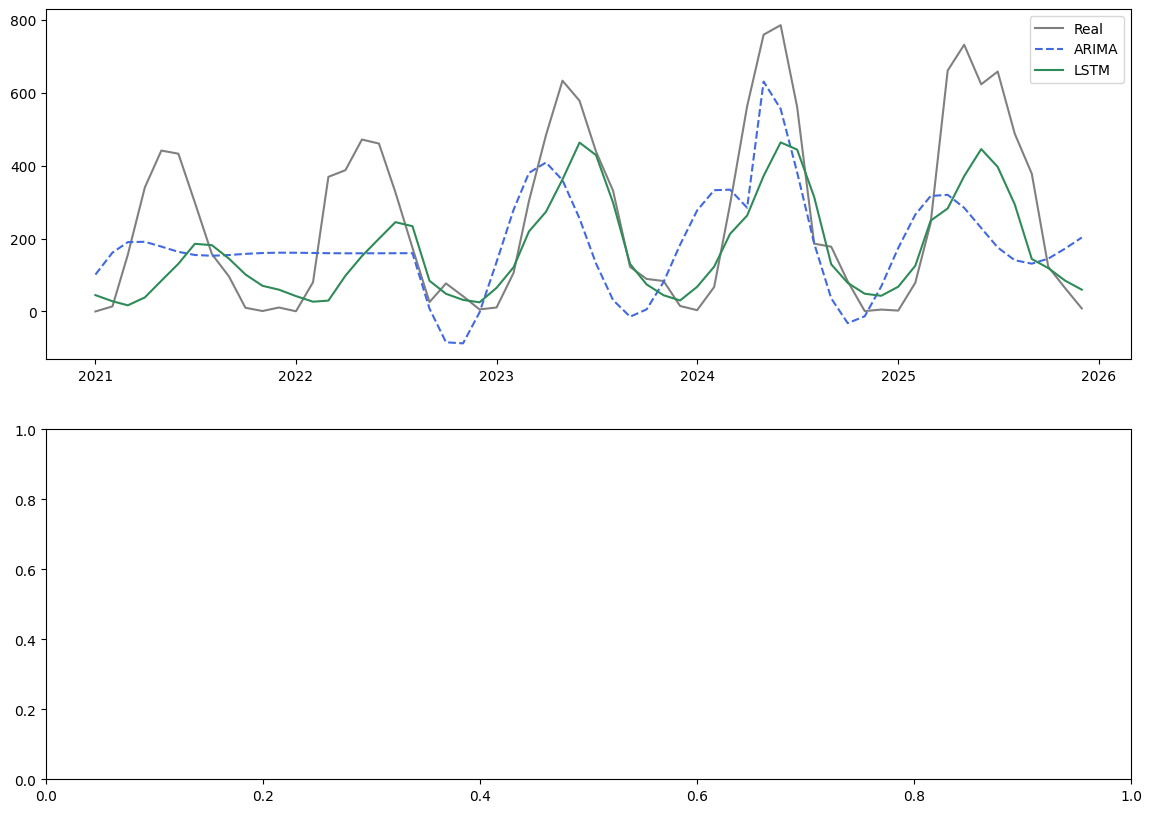


  Roraima
  📂 XLSX → H_EXPORTACAO_GERAL_2015-01_2025-12_DT20260126(3).xlsx
  ✅ Veredicto: LSTM Superior


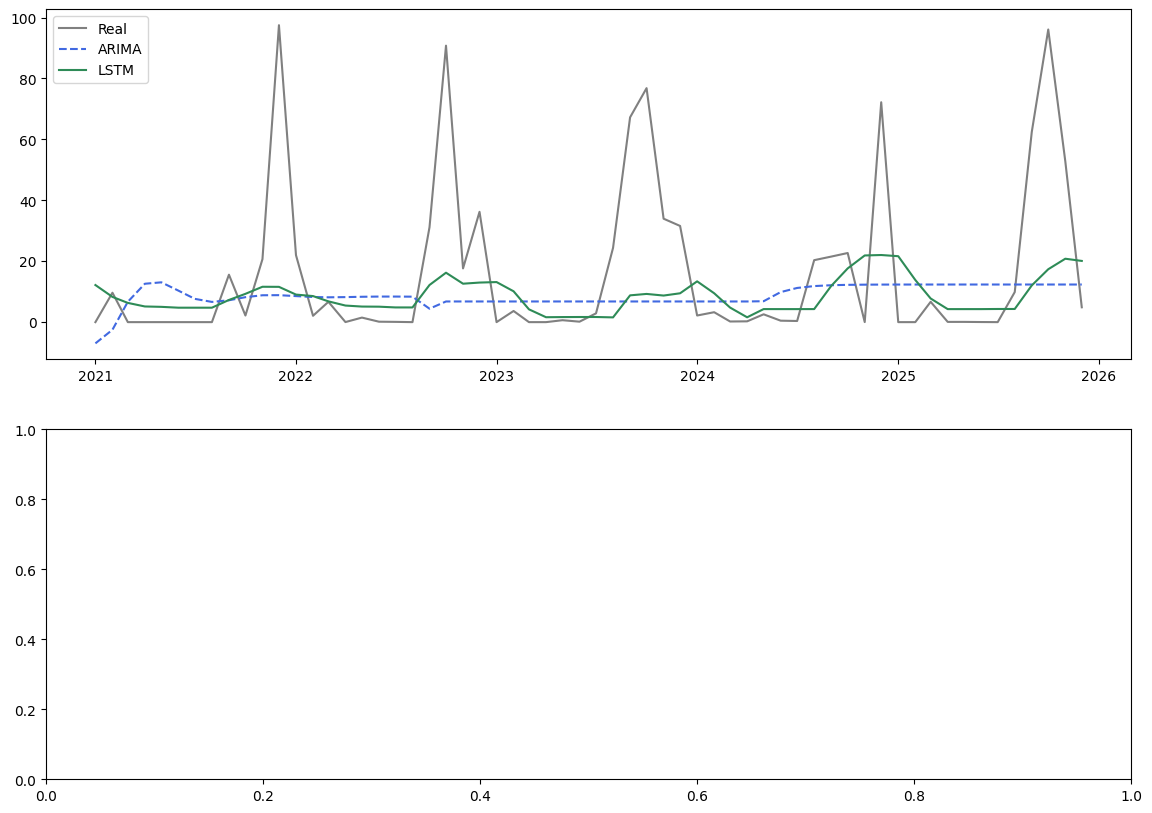

In [36]:
import pmdarima as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

N_LAGS = 3

def criar_sequencias(dados, n_lags):
    X, y = [], []
    for i in range(len(dados) - n_lags):
        X.append(dados[i:(i + n_lags), :])
        y.append(dados[i + n_lags, 0])
    return np.array(X), np.array(y)

def treinar_lstm_parsimoniosa(X_train, y_train, X_val, y_val, lookback, n_features):
    modelo = Sequential([
        LSTM(8, activation='relu', input_shape=(lookback, n_features), kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(1)
    ])
    modelo.compile(optimizer='adam', loss='mse')
    # Ajuste de paciência proporcional para evitar inoperância em dobras curtas
    paciencia_ajustada = min(10, len(X_val))
    early_stop = EarlyStopping(monitor='val_loss', patience=paciencia_ajustada, restore_best_weights=True)
    modelo.fit(X_train, y_train, epochs=50, batch_size=4, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
    return modelo, None

def treinar_arima(serie_alvo, df_processed_local, n_lags):
    y_full = serie_alvo.values
    features_for_alignment = ['Peso_Liquido', 'Valor_FOB', 'Safra_Ativa']
    dados_array_for_alignment = df_processed_local[features_for_alignment].values
    _, y_total_aligned_for_arima = criar_sequencias(dados_array_for_alignment, n_lags)
    tscv = TimeSeriesSplit(n_splits=3)
    previsoes_arima, valores_reais_arima = [], []
    ultima_ordem_arima = None
    for train_index, test_index in tscv.split(y_total_aligned_for_arima):
        y_train_arima = y_full[:train_index[-1] + n_lags + 1]
        y_test_arima = y_total_aligned_for_arima[test_index]
        modelo_arima = pm.auto_arima(y_train_arima, start_p=0, start_q=0, max_p=3, max_q=3, seasonal=False, trace=False, error_action='ignore', suppress_warnings=True, stepwise=True)
        previsoes_arima.extend(modelo_arima.predict(n_periods=len(y_test_arima)))
        valores_reais_arima.extend(y_test_arima)
        ultima_ordem_arima = modelo_arima.order
    return np.array(previsoes_arima), np.array(valores_reais_arima), ultima_ordem_arima

def treinar_lstm(df_input, n_lags):
    features = ['Peso_Liquido', 'Valor_FOB', 'Safra_Ativa']
    dados_array = df_input[features].values
    X_total, y_total = criar_sequencias(dados_array, n_lags)
    tscv = TimeSeriesSplit(n_splits=3)
    all_lstm_preds, all_y_true_lstm, all_dates_lstm = [], [], []
    dates_for_y_total = df_input['Data'].iloc[n_lags:].values
    for train_index, test_index in tscv.split(X_total):
        X_train, X_test = X_total[train_index], X_total[test_index]
        y_train, y_test = y_total[train_index], y_total[test_index]
        scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
        amostras_treino, lags, n_feat = X_train.shape
        X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, n_feat)).reshape(amostras_treino, lags, n_feat)
        X_test_scaled = scaler_X.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], lags, n_feat)
        y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
        val_size = max(1, int(len(X_train_scaled) * 0.15))
        X_tr_sub, y_tr_sub = X_train_scaled[:-val_size], y_train_scaled[:-val_size]
        X_val_st, y_val_st = X_train_scaled[-val_size:], y_train_scaled[-val_size:]
        modelo_lstm, _ = treinar_lstm_parsimoniosa(X_tr_sub, y_tr_sub, X_val_st, y_val_st, lags, n_feat)
        all_lstm_preds.extend(scaler_y.inverse_transform(modelo_lstm.predict(X_test_scaled, verbose=0)).flatten())
        all_y_true_lstm.extend(y_test)
        all_dates_lstm.extend(dates_for_y_total[test_index])
    return np.array(all_lstm_preds), np.array(all_y_true_lstm), np.array(all_dates_lstm)

def executar_pipeline_v2(uf_nome, api_disponivel):
    print(f"\n{'='*55}\n  {uf_nome}\n{'='*55}")
    df_raw = carregar_dados(uf_nome, api_disponivel)
    if df_raw.empty: return
    df_processed = preparar_serie(df_raw, data_corte='2019-01-01', uf=uf_nome)
    pred_arima, y_real_arima, ordem = treinar_arima(df_processed['Peso_Liquido'], df_processed, N_LAGS)
    pred_lstm, y_real_lstm, datas_lstm = treinar_lstm(df_processed, N_LAGS)
    n = min(len(pred_arima), len(pred_lstm))
    # CORREÇÃO: Utilizando a função diebold_mariano_test robusta (definida na célula 1077c378)
    metricas = avaliar_modelos_final(y_real_lstm[:n], pred_arima[:n], pred_lstm[:n])
    print(f"  ✅ Veredicto: {metricas['Veredicto']}")

    tamanho_teste = len(pred_lstm)
    dados_treino_historico = df_processed["Peso_Liquido"].iloc[:-tamanho_teste]
    max_historico_treino = dados_treino_historico.max() if dados_treino_historico.max() > 0 else 1

    df_ipe = pd.DataFrame({'Data': datas_lstm[:n], 'Predicao_kg': pred_lstm[:n], 'IPE_pct': (pred_lstm[:n]/max_historico_treino)*100})

    fig, axes = plt.subplots(2,1, figsize=(14,10))
    axes[0].plot(datas_lstm[:n], y_real_lstm[:n]/1e6, color='gray', label='Real')
    axes[0].plot(datas_lstm[:n], pred_arima[:n]/1e6, ls='--', color='royalblue', label='ARIMA')
    axes[0].plot(datas_lstm[:n], pred_lstm[:n]/1e6, color='seagreen', label='LSTM')
    axes[0].legend(); plt.show()
    resultados_gerais.append({'uf': uf_nome, 'metricas': metricas, 'df_ipe': df_ipe, 'ordem_arima': ordem})

resultados_gerais = []
for uf in UFS_ALVO: executar_pipeline_v2(uf, _verificar_api())

In [41]:
import pandas as pd

# 8. CONSOLIDAÇÃO PARA O ARTIGO ACADÊMICO
print("\n📊 Gerando Tabela Consolidada de Resultados para o Artigo...")

linhas_tabela = []
for res in resultados_gerais:
    linha = {
        'UF': res['uf'],
        'ARIMA_Ordem': str(res['ordem_arima']),
        'RMSE_ARIMA': round(res['metricas']['RMSE_ARIMA'], 2),
        'MAE_ARIMA': round(res['metricas']['MAE_ARIMA'], 2),
        'RMSE_LSTM': round(res['metricas']['RMSE_LSTM'], 2),
        'MAE_LSTM': round(res['metricas']['MAE_LSTM'], 2),
        'DM_Stat': round(res['metricas']['DM_Stat'], 3),
        'DM_p_value': round(res['metricas']['DM_p_value'], 4),
        'Veredicto_Estatistico': res['metricas']['Veredicto']
    }
    linhas_tabela.append(linha)

df_tabela_final = pd.DataFrame(linhas_tabela)

# Exportação
nome_arquivo_exportacao = "Resultados_Finais_Artigo_ECAI.csv"
df_tabela_final.to_csv(nome_arquivo_exportacao, index=False, sep=';', decimal=',')

print(df_tabela_final.to_markdown(index=False))
print(f"\n✅ Tabela exportada com sucesso: {nome_arquivo_exportacao}")
print("Pipeline concluído. Resultados exportados para revisão..")


📊 Gerando Tabela Consolidada de Resultados para o Artigo...
| UF          | ARIMA_Ordem   |   RMSE_ARIMA |   MAE_ARIMA |   RMSE_LSTM |    MAE_LSTM |   DM_Stat |   DM_p_value | Veredicto_Estatistico   |
|:------------|:--------------|-------------:|------------:|------------:|------------:|----------:|-------------:|:------------------------|
| Mato Grosso | (3, 0, 1)     |  1.39625e+09 | 1.10109e+09 | 2.05786e+09 | 1.57982e+09 |    -2.775 |       0.0055 | ARIMA Superior          |
| Amazonas    | (1, 0, 0)     |  2.92206e+06 | 1.99451e+06 | 2.3955e+06  | 1.37158e+06 |     3.349 |       0.0008 | LSTM Superior           |
| Pará        | (3, 0, 0)     |  2.05297e+08 | 1.70399e+08 | 1.71676e+08 | 1.2313e+08  |     2.124 |       0.0337 | LSTM Superior           |
| Roraima     | (1, 0, 0)     |  2.74346e+07 | 1.75571e+07 | 2.5465e+07  | 1.52638e+07 |     2.8   |       0.0051 | LSTM Superior           |

✅ Tabela exportada com sucesso: Resultados_Finais_Artigo_ECAI.csv
Pipeline concluído. 